In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
data = pd.read_csv("Iris.csv")
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
X = data[["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
#find optimal number of clusters using Elbow method
inertia = []
for k in range(1,11):
    model = KMeans(n_clusters = k, random_state = 128, n_init = 10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

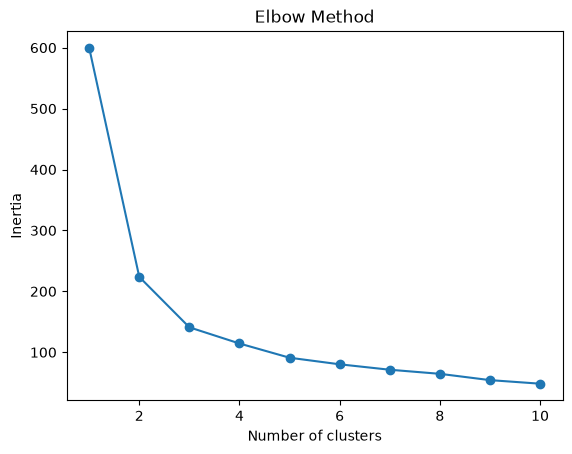

In [6]:
plt.plot(range(1,11), inertia, marker = "o")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [7]:
kmeans = KMeans(n_clusters = 3, random_state = 283, n_init = 10)
clusters = kmeans.fit_predict(X_scaled)
data["Cluster"] = clusters

print("\nClustered Data:")
print(data[[
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm",
    "Cluster"
]].head(20))


Clustered Data:
    SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  Cluster
0             5.1           3.5            1.4           0.2        1
1             4.9           3.0            1.4           0.2        1
2             4.7           3.2            1.3           0.2        1
3             4.6           3.1            1.5           0.2        1
4             5.0           3.6            1.4           0.2        1
5             5.4           3.9            1.7           0.4        1
6             4.6           3.4            1.4           0.3        1
7             5.0           3.4            1.5           0.2        1
8             4.4           2.9            1.4           0.2        1
9             4.9           3.1            1.5           0.1        1
10            5.4           3.7            1.5           0.2        1
11            4.8           3.4            1.6           0.2        1
12            4.8           3.0            1.4           0.1        1
13 

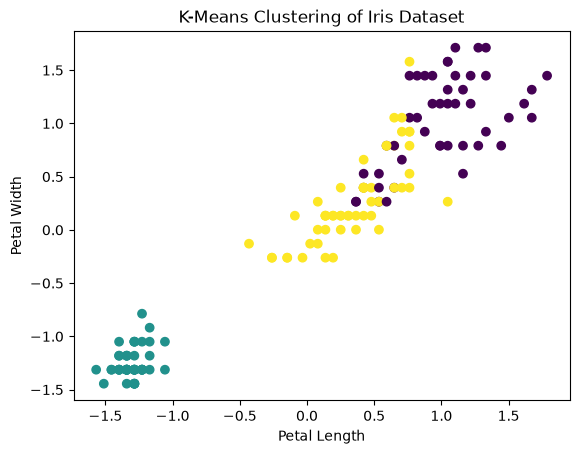

In [8]:
plt.scatter(
    X_scaled[:, 2],
    X_scaled[:, 3],
    c=clusters
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("K-Means Clustering of Iris Dataset")
plt.show()